# Dependencies

In [2]:
import os
import hashlib
os.makedirs("../model", exist_ok=True)

In [3]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [5]:
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from imblearn.over_sampling import SMOTE

In [6]:
%load_ext autoreload
%autoreload 2

from src.dataset import Dataloader

# Fetching dataset

In [7]:
dataloader_config = {
    "time_per_datapoint_s": 1,
}
dataloader = Dataloader(dataloader_config)
dataset = dataloader.get_data()

Dataset already exists. Loading from disk.


In [8]:
dataset

,feat_avg_power,feat_narrowband_power_rate,feat_most_relevant_binned_freq,feat_most_relevant_binned_power,feat_binned_fft_power_bin_0,feat_binned_fft_power_bin_1,feat_binned_fft_power_bin_2,feat_binned_fft_power_bin_3,feat_binned_fft_power_bin_4,feat_binned_fft_power_bin_5,...,feat_dominant_freq,feat_kurtosis,mat_file,sampling_rate,motor_load_hp,motor_speed_rpm,fault_position,fault_type,fault_size_in,telemetry_position
0,0.008065,0.824710,3899.5,437272.747678,0.049988,0.049241,0.072528,0.013876,0.006491,0.019874,...,3634.0,2.335340,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
1,0.008117,0.819063,3899.5,436075.489501,0.061459,0.046462,0.069102,0.014232,0.006098,0.020499,...,3635.0,2.337816,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
2,0.008167,0.810644,3899.5,435844.059116,0.063535,0.049550,0.072450,0.013109,0.006117,0.018417,...,3635.0,2.357269,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
3,0.008125,0.811053,3899.5,433969.830804,0.072614,0.047382,0.065583,0.011873,0.006200,0.019507,...,3635.0,2.340858,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
4,0.008177,0.805523,3899.5,433633.672228,0.078218,0.045019,0.067308,0.012657,0.006586,0.018992,...,3635.0,2.360613,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4133,0.006888,0.139491,299.5,347813.940195,0.614166,0.227633,0.017494,0.136984,0.000465,0.000256,...,0.0,2.964948,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,NaN,NaN,NaN,FE_0
4134,0.006702,0.139884,299.5,339081.688841,0.605874,0.233102,0.019998,0.137822,0.000422,0.000242,...,0.0,3.096287,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,NaN,NaN,NaN,FE_0
4135,0.006555,0.147002,299.5,352049.862321,0.642525,0.190000,0.019218,0.144956,0.000462,0.000237,...,0.0,2.984123,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,NaN,NaN,NaN,FE_0
4136,0.006505,0.145336,299.5,327515.361332,0.609452,0.224490,0.019463,0.143223,0.000458,0.000263,...,0.0,2.974487,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,NaN,NaN,NaN,FE_0


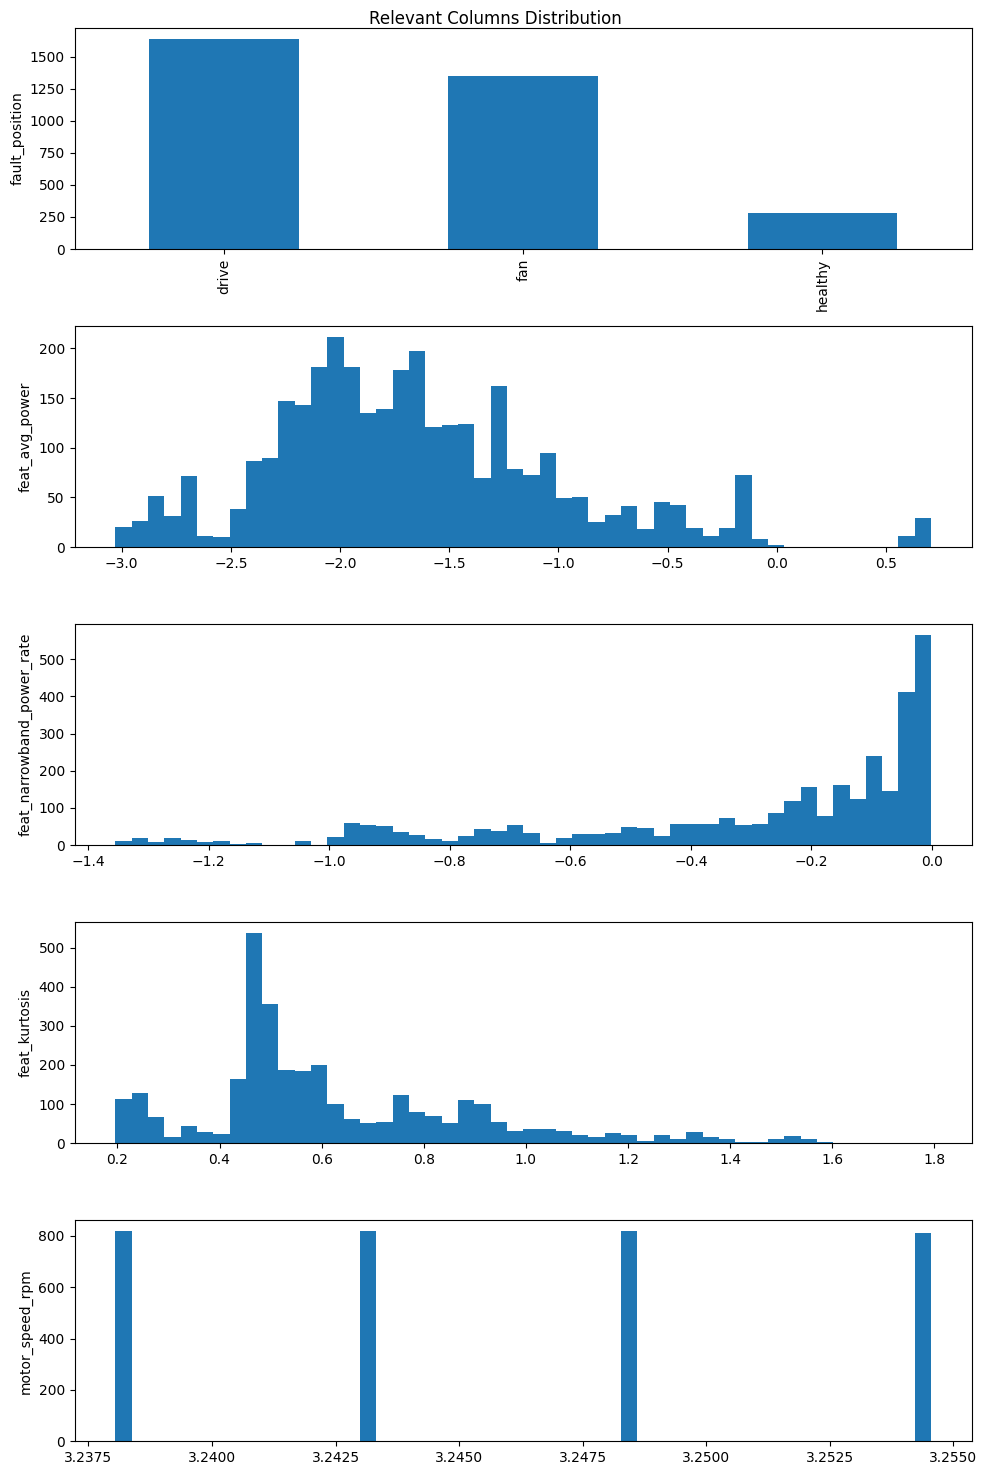

In [9]:
relevant_columns = [
    "fault_position",
    "feat_avg_power",
    "feat_narrowband_power_rate",
    "feat_kurtosis",
    "motor_speed_rpm",
]
curr_dataset = dataset.copy()
healthy_mask = curr_dataset["fault_type"].isna() | curr_dataset["fault_position"].isna()
curr_dataset.loc[healthy_mask, "fault_type"] = "healthy"
curr_dataset.loc[healthy_mask, "fault_position"] = "healthy"

# curr_dataset = curr_dataset[curr_dataset["fault_type"] == "healthy"]

fig, axs = plt.subplots(len(relevant_columns), 1, figsize=(10, 3 * len(relevant_columns)))
for i, col in enumerate(relevant_columns):
    if curr_dataset[col].dtype == "str" or curr_dataset[col].dtype == "category":
        curr_dataset[col] = curr_dataset[col].astype("category")
        curr_dataset[col].value_counts().plot(kind="bar", ax=axs[i])
    elif curr_dataset[col].dtype == "float64" or curr_dataset[col].dtype == "int64":
        curr_dataset[col].apply(np.log10).hist(bins=50, ax=axs[i])
    else:
        print(f"Column {col} has unsupported dtype {curr_dataset[col].dtype}")
        continue
    axs[i].set_ylabel(col)
    axs[i].set_xlabel("")
    axs[i].grid(False)

fig.suptitle("Relevant Columns Distribution")
fig.tight_layout()

Theres an imbalance between the classes, so we must develop some method to oversample the healthy label later on. 

Logarithms may be applied to the data in order to distribute more evenly the feature values.

In [10]:
def k_fold(
        dataset: pd.DataFrame, 
        k: int = 5, 
        oversample: bool = False,
        input_columns:list = ["feat_avg_power","feat_narrowband_power_rate"],
        output_columns:list = ["has_fault"]
    ):
    
    X = dataset[input_columns].values
    y = dataset[output_columns].values

    folds = np.array_split(np.arange(len(X)), k)
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        if oversample:
            n_per_class = np.unique(y[train_idx], return_counts=True) # [[labels], [counts]]
            diffs = n_per_class[1].max() - n_per_class[1]
            for class_value, n_samples in zip(n_per_class[0], diffs):
                if n_samples > 0:
                    class_idx = train_idx[y[train_idx] == class_value]
                    oversampled_idx = np.random.choice(class_idx, size=n_samples, replace=True)
                    train_idx = np.concatenate([train_idx, oversampled_idx])

        yield X[train_idx], y[train_idx], X[test_idx], y[test_idx]

# Model Proposal 1

A model that detects if theres a fault at all, not discriminating type or position relative to sensor. It receives one sensor readings and computes how likely that signal represents a fault.
- classifier based on features
- anomaly detection on the time series (moving window z-score or other metrics)

In [ ]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
curr_dataset["has_fault"] = curr_dataset["fault_type"].notna()
curr_dataset["feat_avg_power"] = curr_dataset["feat_avg_power"].apply(np.log1p)
curr_dataset["feat_narrowband_power_rate"] = curr_dataset["feat_narrowband_power_rate"].apply(np.log1p)
curr_dataset["feat_kurtosis"] = curr_dataset["feat_kurtosis"].apply(np.log1p)

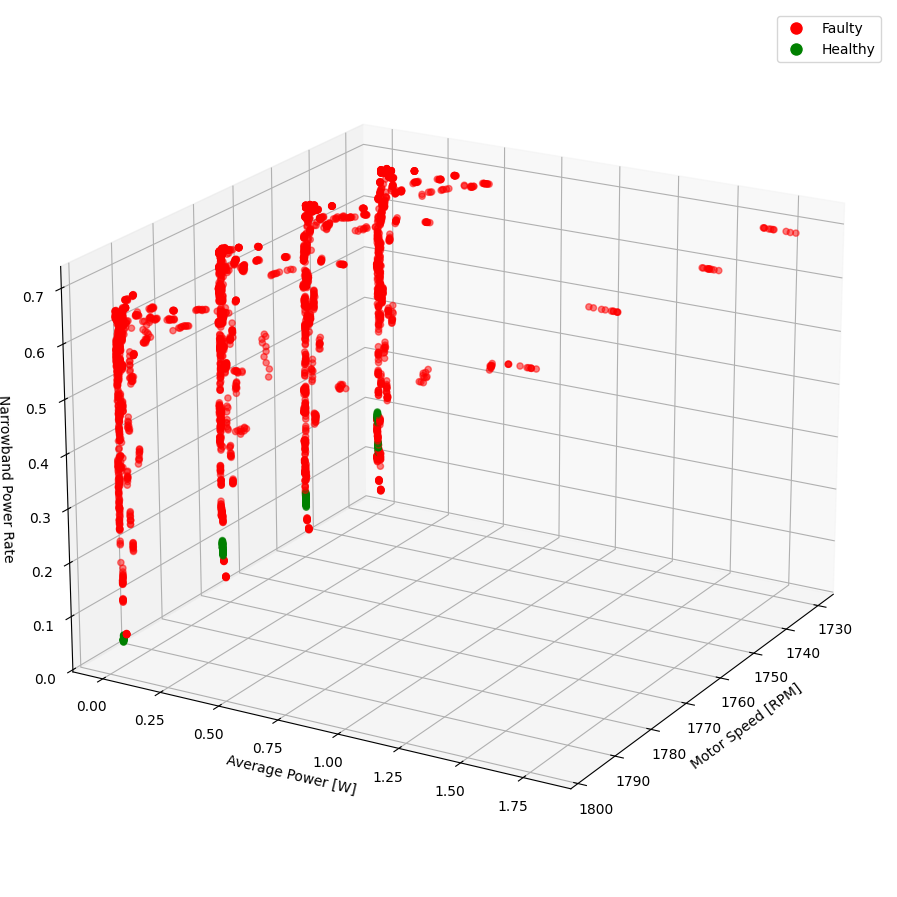

In [219]:
fig = plt.figure(figsize=(8,6),dpi=100)
ax = fig.add_subplot(projection='3d', elev=20, azim=30)

ax.scatter(
    xs=curr_dataset["motor_speed_rpm"],
    ys=curr_dataset["feat_avg_power"],
    zs=curr_dataset["feat_narrowband_power_rate"],
    c=curr_dataset["has_fault"].map({True: "red", False: "green"}),
    alpha=0.5,
)
ax.set_xlabel("Motor Speed [RPM]")
ax.set_ylabel("Average Power [W]")
ax.set_zlabel("Narrowband Power Rate")
ax.legend(handles=[
    plt.plot([],[], marker='o', color='w', label='Faulty', markerfacecolor='red', markersize=10)[0],
    plt.plot([],[], marker='o', color='w', label='Healthy', markerfacecolor='green', markersize=10)[0]
])
fig.tight_layout(pad=-10)

In [220]:
models = {
    "XGBClassifier": XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        scale_pos_weight=curr_dataset["has_fault"].value_counts()[False] / curr_dataset["has_fault"].value_counts()[True],
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "SVC": make_pipeline(StandardScaler(), SVC(class_weight='balanced')),
}

In [221]:
preds = defaultdict(lambda: defaultdict(list))
best_xgb_score = 0
for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(curr_dataset, k=5):
        model.fit(X_train, y_train.ravel())
        # score = model.score(X_test, y_test)
        # classification_report_str = classification_report(y_test, y_pred, target_names=["Healthy", "Faulty"])
        y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test.ravel(), y_pred)
        preds[model_name]["cm"].append(cm)
        tn, fp, fn, tp = cm.ravel()
        preds[model_name]["recall"].append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        preds[model_name]["specificity"].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        preds[model_name]["precision"].append(tp / (tp + fp) if (tp + fp) > 0 else 0)

In [222]:
print("Model Performance Metrics:")
for model_name in preds.keys():
    recall_min = np.min(preds[model_name]['recall']) * 100
    recall_max = np.max(preds[model_name]['recall']) * 100
    specificity_min = np.min(preds[model_name]['specificity']) * 100
    specificity_max = np.max(preds[model_name]['specificity']) * 100
    precision_min = np.min(preds[model_name]['precision']) * 100
    precision_max = np.max(preds[model_name]['precision']) * 100

    print(f"{model_name}:")
    print(f"\tRecall: [{recall_min:.2f}, {recall_max:.2f}]")
    print(f"\tSpecificity: [{specificity_min:.2f}, {specificity_max:.2f}]")
    print(f"\tPrecision: [{precision_min:.2f}, {precision_max:.2f}]")

Model Performance Metrics:
XGBClassifier:
	Recall: [99.33, 100.00]
	Specificity: [100.00, 100.00]
	Precision: [100.00, 100.00]
DecisionTreeClassifier:
	Recall: [99.66, 100.00]
	Specificity: [97.87, 100.00]
	Precision: [99.83, 100.00]
SVC:
	Recall: [87.08, 89.67]
	Specificity: [100.00, 100.00]
	Precision: [100.00, 100.00]


# Model Proposal 2
A multi-label classifier, to separate between types. In order to do that, it may be needed to extract patterns from the time series or its fft format for each fault.

- Extract the FFT -> train an auto-encoder as an embedding -> use its latent variables as input
- Collect the power from every telemetry position in order to determine the expected power from each fault at each position

Its still receives one sensor reading to make the inference.

In [101]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
faulty_dataset = curr_dataset.copy()

In [102]:
curr_dataset["feat_avg_power"] = curr_dataset["feat_avg_power"].apply(np.log1p)
curr_dataset["feat_narrowband_power_rate"] = curr_dataset["feat_narrowband_power_rate"].apply(np.log1p)
curr_dataset["feat_kurtosis"] = curr_dataset["feat_kurtosis"].apply(np.log1p)

faulty_dataset["fault_size_in"] = faulty_dataset["fault_size_in"].apply(lambda x: x if pd.notna(x) else 0)
faulty_dataset["fault_type"] = faulty_dataset["fault_type"].apply(lambda x: "none" if not pd.notna(x) else "outer" if "outer" in x else x)
faults = faulty_dataset["fault_type"].unique().tolist()

encoder = OneHotEncoder()
encoded_fault_types = encoder.fit_transform(faulty_dataset[['fault_type']])
encoded_fault_types_df = pd.DataFrame(encoded_fault_types.toarray(), columns=encoder.get_feature_names_out(['fault_type']))
oh_faulty_dataset = pd.concat([faulty_dataset.drop(columns=['fault_type']).reset_index(drop=True), encoded_fault_types_df.reset_index(drop=True)], axis=1)
faulty_dataset.head()

,feat_avg_power,feat_narrowband_power_rate,feat_most_relevant_binned_freq,feat_most_relevant_binned_power,feat_binned_fft_power_bin_0,feat_binned_fft_power_bin_1,feat_binned_fft_power_bin_2,feat_binned_fft_power_bin_3,feat_binned_fft_power_bin_4,feat_binned_fft_power_bin_5,...,feat_dominant_freq,feat_kurtosis,mat_file,sampling_rate,motor_load_hp,motor_speed_rpm,fault_position,fault_type,fault_size_in,telemetry_position
1644,0.030597,0.563379,3299.5,4.715286e+05,0.142834,0.130920,0.056450,0.068233,0.124684,0.206198,...,0.0,3.776068,/home/lmres/storage/projects/cwru-fault-detect...,12000,1,1772,drive,inner,0.021,FE_0
134,0.032860,0.830083,3299.5,1.622660e+06,0.091432,0.046100,0.027464,0.011935,0.118619,0.685526,...,3217.0,3.729576,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.014,DE_0
411,0.013692,0.355986,299.5,3.623209e+05,0.350284,0.105981,0.003803,0.010004,0.050861,0.136061,...,0.0,2.925111,/home/lmres/storage/projects/cwru-fault-detect...,12000,1,1772,fan,ball,0.007,FE_0
203,0.017697,0.691002,3899.5,4.404319e+05,0.058012,0.094751,0.112856,0.015492,0.135185,0.112240,...,4120.0,5.611338,/home/lmres/storage/projects/cwru-fault-detect...,12000,2,1750,fan,inner,0.014,FE_0
1159,0.009691,0.797814,3299.5,3.471136e+05,0.060237,0.109422,0.022317,0.030742,0.251536,0.497018,...,2910.0,3.483902,/home/lmres/storage/projects/cwru-fault-detect...,12000,1,1772,fan,outer,0.021,DE_0


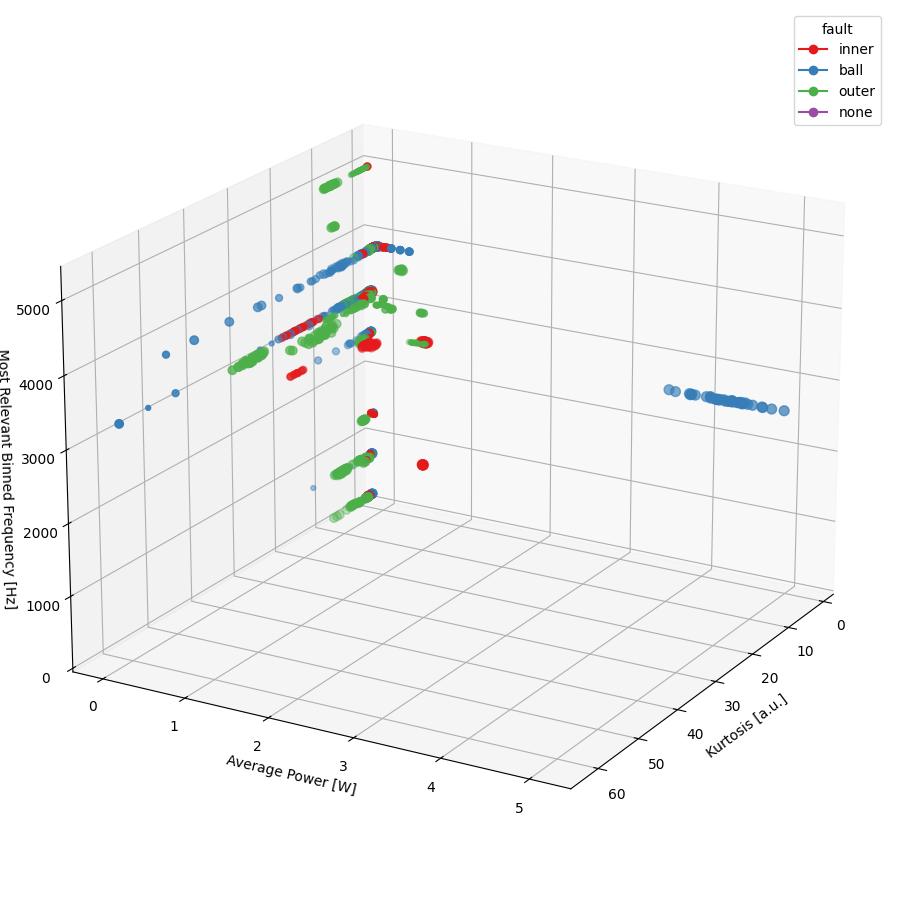

In [107]:
fig = plt.figure(figsize=(8,6),dpi=100)
ax = fig.add_subplot(projection='3d', elev=20, azim=30)

faulty_dataset["fault_type_c"] = faulty_dataset["fault_type"].apply(lambda x: faults.index(x))
cmap = plt.get_cmap("Set1")

ax.scatter(
    xs=faulty_dataset["feat_kurtosis"],
    ys=faulty_dataset["feat_avg_power"],
    zs=faulty_dataset["feat_most_relevant_binned_freq"],
    c=cmap(faulty_dataset["fault_type_c"]),
    s=50*(faulty_dataset["fault_size_in"]-faulty_dataset["fault_size_in"].min())/(faulty_dataset["fault_size_in"].max()-faulty_dataset["fault_size_in"].min()),
)
# ax.set_xlabel("Motor Speed [RPM]")
ax.set_xlabel("Kurtosis [a.u.]")
ax.set_ylabel("Average Power [W]")
# ax.set_zlabel("Narrowband Power Rate")
ax.set_zlabel("Most Relevant Binned Frequency [Hz]")

handles = []
for i,label in enumerate(faults):
    handles.append(
        plt.plot([],[],label=label,color=cmap(i),marker='o')[0]
    )

ax.legend(title="fault")
fig.tight_layout(pad=-10)

In [226]:
models = {
    "xgboost": XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        tree_method="hist"
    )
}

In [227]:
metrics = defaultdict(lambda: defaultdict(list))
input_columns = ["feat_avg_power","feat_narrowband_power_rate","feat_kurtosis"]\
    +dataset.filter(like="binned").columns.tolist()\
    +["feat_dominant_freq"]
output_columns = encoder.get_feature_names_out(["fault_type"])


for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(oh_faulty_dataset, k=5,input_columns=input_columns, output_columns=output_columns):

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        for i,label in enumerate(output_columns):
            recall = recall_score(y_test[:, i], y_pred[:, i], average='micro')
            metrics[model_name][f"recall_{label}"].append(recall)
        
        acc = (y_test == y_pred).mean()
        metrics[model_name]["accuracy"].append(acc)

In [228]:
print("Recall for each label")
for model_name in metrics.keys():
    print(f"{model_name}:")
    for label in metrics[model_name].keys():
        if label.startswith("recall_"):
            recall_min = np.min(metrics[model_name][label]) * 100
            recall_max = np.max(metrics[model_name][label]) * 100
            print(f"\t{label}: [{recall_min:.2f}, {recall_max:.2f}]")
    if "accuracy" in metrics[model_name]:
        acc_min = np.min(metrics[model_name]["accuracy"]) * 100
        acc_max = np.max(metrics[model_name]["accuracy"]) * 100
        print(f"\taccuracy: [{acc_min:.2f}, {acc_max:.2f}]")

Recall for each label
xgboost:
	recall_fault_type_ball: [89.30, 94.50]
	recall_fault_type_inner: [92.97, 96.02]
	recall_fault_type_none: [99.85, 100.00]
	recall_fault_type_outer: [86.85, 91.28]
	accuracy: [92.43, 94.46]


# Model Proposal 3
Detect the position from different telemetry positions. Firstly, we must test whether the telemetry position helps detecting the closest fault position.

## Limited dataset

In [229]:
curr_dataset = oh_faulty_dataset.copy()
curr_dataset["fault_position"] = curr_dataset["fault_position"].apply(lambda x: "none" if not pd.notna(x) else "drive" if "drive" in x else x)
curr_dataset["has_fault"] = curr_dataset["fault_position"].apply(lambda x: int(x != "none"))
curr_dataset["telemetry_position"] = curr_dataset["telemetry_position"].map({
    "FE_0":"fan",
    "DE_0":"drive",
    "BA_0":"base"
})

In [230]:
print(curr_dataset["fault_position"].unique())
print(curr_dataset["telemetry_position"].unique())

<StringArray>
['drive', 'fan', 'none']
Length: 3, dtype: str
<StringArray>
['fan', 'drive', 'base']
Length: 3, dtype: str


In [231]:
limited_dataset = curr_dataset[(curr_dataset["fault_position"] == curr_dataset["telemetry_position"]) | (curr_dataset["fault_position"] == "none")]
limited_dataset

,feat_avg_power,feat_narrowband_power_rate,feat_most_relevant_binned_freq,feat_most_relevant_binned_power,feat_binned_fft_power_bin_0,feat_binned_fft_power_bin_1,feat_binned_fft_power_bin_2,feat_binned_fft_power_bin_3,feat_binned_fft_power_bin_4,feat_binned_fft_power_bin_5,...,motor_load_hp,motor_speed_rpm,fault_position,fault_size_in,telemetry_position,fault_type_ball,fault_type_inner,fault_type_none,fault_type_outer,has_fault
2,0.013692,0.355986,299.5,3.623209e+05,0.350284,0.105981,0.003803,0.010004,0.050861,0.136061,...,1,1772,fan,0.007,fan,1.0,0.0,0.0,0.0,1
3,0.017697,0.691002,3899.5,4.404319e+05,0.058012,0.094751,0.112856,0.015492,0.135185,0.112240,...,2,1750,fan,0.014,fan,0.0,1.0,0.0,0.0,1
9,0.084876,0.931664,3299.5,3.017234e+06,0.031224,0.027513,0.004004,0.006625,0.071041,0.488268,...,1,1772,fan,0.021,fan,0.0,1.0,0.0,0.0,1
11,0.022284,0.872234,3299.5,1.152190e+06,0.092898,0.025945,0.007426,0.002944,0.137345,0.717466,...,1,1772,drive,0.014,drive,1.0,0.0,0.0,0.0,1
12,0.179545,0.954941,3299.5,1.162222e+07,0.005048,0.027753,0.005260,0.002347,0.036252,0.898844,...,0,1797,fan,0.014,fan,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3263,0.206195,0.947330,2699.5,8.529084e+06,0.026807,0.015048,0.006626,0.008489,0.574467,0.361543,...,1,1772,drive,0.021,drive,0.0,1.0,0.0,0.0,1
3264,0.005693,0.109481,299.5,2.798362e+05,0.578539,0.289183,0.021881,0.107204,0.000377,0.000325,...,1,1772,none,0.000,fan,0.0,0.0,1.0,0.0,0
3266,0.540339,0.963068,3299.5,3.656457e+07,0.001289,0.027129,0.005455,0.005287,0.010362,0.939796,...,3,1730,fan,0.014,fan,0.0,0.0,0.0,1.0,1
3268,0.912724,0.798644,3299.5,4.484169e+07,0.185882,0.005488,0.002497,0.017815,0.087607,0.619469,...,0,1797,fan,0.014,fan,0.0,0.0,0.0,1.0,1


In [235]:
metrics = defaultdict(lambda: defaultdict(list))
input_columns = ["feat_avg_power","feat_narrowband_power_rate","feat_kurtosis"]\
    +limited_dataset.filter(like="binned").columns.tolist()\
    +["feat_dominant_freq"]
output_columns = encoder.get_feature_names_out(["fault_type"])
# output_columns = ["has_fault"]

for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(limited_dataset, k=5,input_columns=input_columns, output_columns=output_columns):

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if "has_fault" in output_columns:
            y_test = y_test.reshape(-1, 1)
            y_pred = y_pred.reshape(-1, 1)
        for i,label in enumerate(output_columns):
            recall = recall_score(y_test[:, i], y_pred[:, i])
            metrics[model_name][f"recall_{label}"].append(recall)
        
        acc = (y_test == y_pred).mean()
        metrics[model_name]["accuracy"].append(acc)

In [ ]:
print("Recall for each label")
for model_name in metrics.keys():
    print(f"{model_name}:")
    for label in metrics[model_name].keys():
        if label.startswith("recall_"):
            recall_min = np.min(metrics[model_name][label]) * 100
            recall_max = np.max(metrics[model_name][label]) * 100
            print(f"\t{label}: [{recall_min:.2f}, {recall_max:.2f}]")
    if "accuracy" in metrics[model_name]:
        acc_min = np.min(metrics[model_name]["accuracy"]) * 100
        acc_max = np.max(metrics[model_name]["accuracy"]) * 100
        print(f"\taccuracy: [{acc_min:.2f}, {acc_max:.2f}]")

Recall for each label
xgboost:
	recall_fault_type_ball: [95.95, 100.00]
	recall_fault_type_inner: [95.92, 100.00]
	recall_fault_type_none: [100.00, 100.00]
	recall_fault_type_outer: [96.84, 99.01]
	accuracy: [98.97, 99.44]


Therefore, the telemetry position can be used to infer the fault in the nearest bearing position.

## Accuracy per telemetry position

In [238]:
encoder = OneHotEncoder()
encoded_fault_types = encoder.fit_transform(curr_dataset[['fault_position']])
encoded_fault_types_df = pd.DataFrame(encoded_fault_types.toarray(), columns=encoder.get_feature_names_out(['fault_position']))
curr_oh_dataset = pd.concat([curr_dataset.drop(columns=['fault_position']).reset_index(drop=True), encoded_fault_types_df.reset_index(drop=True)], axis=1)
curr_oh_dataset.head()

,feat_avg_power,feat_narrowband_power_rate,feat_most_relevant_binned_freq,feat_most_relevant_binned_power,feat_binned_fft_power_bin_0,feat_binned_fft_power_bin_1,feat_binned_fft_power_bin_2,feat_binned_fft_power_bin_3,feat_binned_fft_power_bin_4,feat_binned_fft_power_bin_5,...,fault_size_in,telemetry_position,fault_type_ball,fault_type_inner,fault_type_none,fault_type_outer,has_fault,fault_position_drive,fault_position_fan,fault_position_none
0,0.030597,0.563379,3299.5,4.715286e+05,0.142834,0.130920,0.056450,0.068233,0.124684,0.206198,...,0.021,fan,0.0,1.0,0.0,0.0,1,1.0,0.0,0.0
1,0.032860,0.830083,3299.5,1.622660e+06,0.091432,0.046100,0.027464,0.011935,0.118619,0.685526,...,0.014,drive,0.0,1.0,0.0,0.0,1,0.0,1.0,0.0
2,0.013692,0.355986,299.5,3.623209e+05,0.350284,0.105981,0.003803,0.010004,0.050861,0.136061,...,0.007,fan,1.0,0.0,0.0,0.0,1,0.0,1.0,0.0
3,0.017697,0.691002,3899.5,4.404319e+05,0.058012,0.094751,0.112856,0.015492,0.135185,0.112240,...,0.014,fan,0.0,1.0,0.0,0.0,1,0.0,1.0,0.0
4,0.009691,0.797814,3299.5,3.471136e+05,0.060237,0.109422,0.022317,0.030742,0.251536,0.497018,...,0.021,drive,0.0,0.0,0.0,1.0,1,0.0,1.0,0.0


In [239]:
metrics = defaultdict(lambda: defaultdict(list))
input_columns = ["feat_avg_power","feat_narrowband_power_rate","feat_kurtosis"]\
    +curr_oh_dataset.filter(like="binned").columns.tolist()\
    +["feat_dominant_freq"]

output_columns = encoder.get_feature_names_out(["fault_position"])
# output_columns = ["has_fault"]

for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(curr_oh_dataset, k=5,input_columns=input_columns, output_columns=output_columns):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        if "has_fault" in output_columns:
            y_test = y_test.reshape(-1, 1)
            y_pred = y_pred.reshape(-1, 1)
        for i,label in enumerate(output_columns):
            recall = recall_score(y_test[:, i], y_pred[:, i])
            metrics[model_name][f"recall_{label}"].append(recall)
        
        acc = (y_test == y_pred).mean()
        metrics[model_name]["accuracy"].append(acc)

In [240]:
print("Results for fault position inference")
for k,v in metrics.items():
    print(f"Model: {k}")
    for metric_name, values in v.items():
        print(f"  {metric_name}: {sum(values)/len(values) if values else 0}")

Results for fault position inference
Model: xgboost
  recall_fault_position_drive: 0.987336392470675
  recall_fault_position_fan: 0.9936251718848561
  recall_fault_position_none: 0.9962962962962963
  accuracy: 0.9938837920489295


# Model storage

In [76]:
from src.model import Preprocessor

In [77]:
def save_model(model, prefix="fault_binary"):
    model_hash = hashlib.md5(model.__str__().encode()).hexdigest()
    model.save_model(f"../model/{prefix}_{model_hash}.json")
    return

## Binary fault classification

In [78]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
curr_dataset["has_fault"] = curr_dataset["fault_type"].apply(lambda x: int(pd.notna(x)))

input_columns = ["feat_avg_power","feat_narrowband_power_rate","feat_kurtosis","feat_dominant_freq"]
input_columns += curr_dataset.filter(like="binned").columns.tolist()
output_columns = ["has_fault"]

In [79]:
oversampled = SMOTE(random_state=42).fit_resample(
    curr_dataset[input_columns],
    curr_dataset[output_columns]
)

print("Before:", curr_dataset[input_columns].shape, curr_dataset[output_columns].value_counts().to_dict())
print("After:", oversampled[0].shape, oversampled[1].value_counts().to_dict())

Before: (3270, 16) {(1,): 2990, (0,): 280}
After: (5980, 16) {(1,): 2990, (0,): 2990}


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    oversampled[0],
    oversampled[1],
    test_size=0.2,
    random_state=42
)

In [81]:
preprocessor = Preprocessor(numerical_cols=input_columns, categorical_cols=[])

class_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
model = XGBClassifier(
    n_estimators=10, 
    max_depth=3, 
    learning_rate=1, 
    objective='binary:logistic',
    # scale_pos_weight=class_ratio,
)

pipeline = make_pipeline(
    preprocessor,
    model
)

In [82]:
params = {
    "xgbclassifier__eval_set": [(X_test, y_test)],
    "xgbclassifier__verbose": True,
}
pipeline.fit(X_train,y_train,**params)

[0]	validation_0-logloss:1.12566
[1]	validation_0-logloss:1.60685
[2]	validation_0-logloss:2.09598
[3]	validation_0-logloss:2.58043
[4]	validation_0-logloss:3.04565
[5]	validation_0-logloss:3.46732
[6]	validation_0-logloss:3.81697
[7]	validation_0-logloss:4.08506
[8]	validation_0-logloss:4.08506
[9]	validation_0-logloss:4.08506


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,numerical_cols,"['feat_avg_power', 'feat_narrowband_power_rate', ...]"
,categorical_cols,[]
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [84]:
recall = recall_score(y_test, pipeline.predict(X_test))
accuracy = accuracy_score(y_test, pipeline.predict(X_test))

print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")

print("Results per fault")
print(classification_report(y_test, pipeline.predict(X_test)))
print("Confusion Matrix")
print(confusion_matrix(y_test, pipeline.predict(X_test)))

Recall: 0.47491638795986624
Accuracy: 0.7374581939799331
Results per fault
              precision    recall  f1-score   support

           0       0.66      1.00      0.79       598
           1       1.00      0.47      0.64       598

    accuracy                           0.74      1196
   macro avg       0.83      0.74      0.72      1196
weighted avg       0.83      0.74      0.72      1196

Confusion Matrix
[[598   0]
 [314 284]]


In [85]:
save_model(pipeline.steps[-1][1],f"fault_binary")

## Multi label fault classification

In [86]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
curr_dataset["has_fault"] = curr_dataset["fault_type"].apply(lambda x: int(pd.notna(x)))

input_columns = ["feat_avg_power","feat_narrowband_power_rate","feat_kurtosis","feat_dominant_freq"]
input_columns += curr_dataset.filter(like="binned").columns.tolist()

curr_dataset["fault_type"] = curr_dataset["fault_type"].fillna("none").map(lambda x: "outer" if "outer" in x else x)
print(curr_dataset["fault_type"].value_counts())
encoder = OneHotEncoder()
encoded_fault_types = encoder.fit_transform(curr_dataset[['fault_type']])
encoded_fault_types_df = pd.DataFrame(encoded_fault_types.toarray(), columns=encoder.get_feature_names_out(['fault_type']))
curr_dataset = pd.concat([curr_dataset.drop(columns=['fault_type']).reset_index(drop=True), encoded_fault_types_df.reset_index(drop=True)], axis=1)    
output_columns = encoder.get_feature_names_out(['fault_type']).tolist()

fault_type
outer    1470
inner     760
ball      760
none      280
Name: count, dtype: int64


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    curr_dataset[input_columns],
    curr_dataset[output_columns],
    test_size=0.2,
    random_state=42
)

In [88]:
preprocessor = Preprocessor(
    numerical_cols=input_columns,
    categorical_cols=[]
)

model = XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        tree_method="hist"
    )

pipeline = make_pipeline(
    preprocessor,
    model
)

In [89]:
pipeline.fit(X_train, y_train)

print("Response columns:", y_test.columns.tolist())
print("Results per fault")
print(classification_report(y_test, pipeline.predict(X_test)))

Response columns: ['fault_type_ball', 'fault_type_inner', 'fault_type_none', 'fault_type_outer']
Results per fault
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       156
           1       0.93      0.86      0.89       170
           2       1.00      1.00      1.00        54
           3       0.81      0.83      0.82       274

   micro avg       0.87      0.84      0.86       654
   macro avg       0.90      0.87      0.88       654
weighted avg       0.87      0.84      0.86       654
 samples avg       0.80      0.84      0.82       654



/home/lmres/storage/projects/cwru-fault-detection/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [91]:
save_model(pipeline.steps[-1][1],"fault_multiclass")

## Multi label fault position

In [95]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
curr_dataset["has_fault"] = curr_dataset["fault_type"].apply(lambda x: int(pd.notna(x)))

input_columns = ["feat_avg_power","feat_narrowband_power_rate","feat_kurtosis","feat_dominant_freq"]
input_columns += curr_dataset.filter(like="binned").columns.tolist()

curr_dataset["fault_position"] = curr_dataset["fault_position"].fillna("none").map(lambda x: "outer" if "outer" in x else x)
print(curr_dataset["fault_position"].value_counts())
encoder = OneHotEncoder()
encoded_fault_positions = encoder.fit_transform(curr_dataset[['fault_position']])
encoded_fault_positions_df = pd.DataFrame(encoded_fault_positions.toarray(), columns=encoder.get_feature_names_out(['fault_position']))
curr_dataset = pd.concat([curr_dataset.drop(columns=['fault_position']).reset_index(drop=True), encoded_fault_positions_df.reset_index(drop=True)], axis=1)    
output_columns = encoder.get_feature_names_out(['fault_position']).tolist()

fault_position
drive    1640
fan      1350
none      280
Name: count, dtype: int64


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    curr_dataset[input_columns],
    curr_dataset[output_columns],
    test_size=0.2,
    random_state=42
)

In [94]:
preprocessor = Preprocessor(
    numerical_cols=input_columns,
    categorical_cols=[]
)

model = XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        tree_method="hist"
    )

pipeline = make_pipeline(
    preprocessor,
    model
)

In [97]:
pipeline.fit(X_train, y_train)

print("Response columns:", y_test.columns.tolist())
print("Results per fault")
print(classification_report(y_test, pipeline.predict(X_test)))

Response columns: ['fault_position_drive', 'fault_position_fan', 'fault_position_none']
Results per fault
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       312
           1       0.99      0.98      0.98       288
           2       1.00      1.00      1.00        54

   micro avg       0.99      0.98      0.99       654
   macro avg       1.00      0.99      0.99       654
weighted avg       0.99      0.98      0.99       654
 samples avg       0.98      0.98      0.98       654



/home/lmres/storage/projects/cwru-fault-detection/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [98]:
save_model(pipeline.steps[-1][1],"position_multiclass")